In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import math

In [2]:
df = pd.read_csv("TATAMOTORS.NS.csv") 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4233 entries, 0 to 4232
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4233 non-null   object 
 1   Open       4226 non-null   float64
 2   High       4226 non-null   float64
 3   Low        4226 non-null   float64
 4   Close      4226 non-null   float64
 5   Adj Close  4226 non-null   float64
 6   Volume     4226 non-null   float64
dtypes: float64(6), object(1)
memory usage: 231.6+ KB


In [4]:
print(df.isnull().sum())


Date         0
Open         7
High         7
Low          7
Close        7
Adj Close    7
Volume       7
dtype: int64


In [5]:
df = df[['Close']]  
df.head

<bound method NDFrame.head of            Close
0     161.515854
1     169.085266
2     169.209824
3     168.912796
4     171.068634
...          ...
4228  812.450012
4229  818.849976
4230  805.549988
4231  819.049988
4232  823.549988

[4233 rows x 1 columns]>

In [6]:
df = df.fillna(method='ffill')

C:\Users\jaina\AppData\Local\Temp\ipykernel_14044\569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        Y.append(dataset[i, 0])
    return np.array(X), np.array(Y)

X_train, Y_train = create_dataset(train_data)
X_test, Y_test = create_dataset(test_data)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [8]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


C:\Users\jaina\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(X_train, Y_train, epochs=50, batch_size=32)


Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0171
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0018
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0015
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0015
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0014
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0013
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0012
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0010
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0010
Epoch 10/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 9.5307e-04
Epoch 11/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 8.0841e-04
Epoch 12/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 8.3713e-04
Epoch 13/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 9.0229e-04
Epoch 14/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 8.4442e-04
Epoch 15/50
104/104 ━━

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


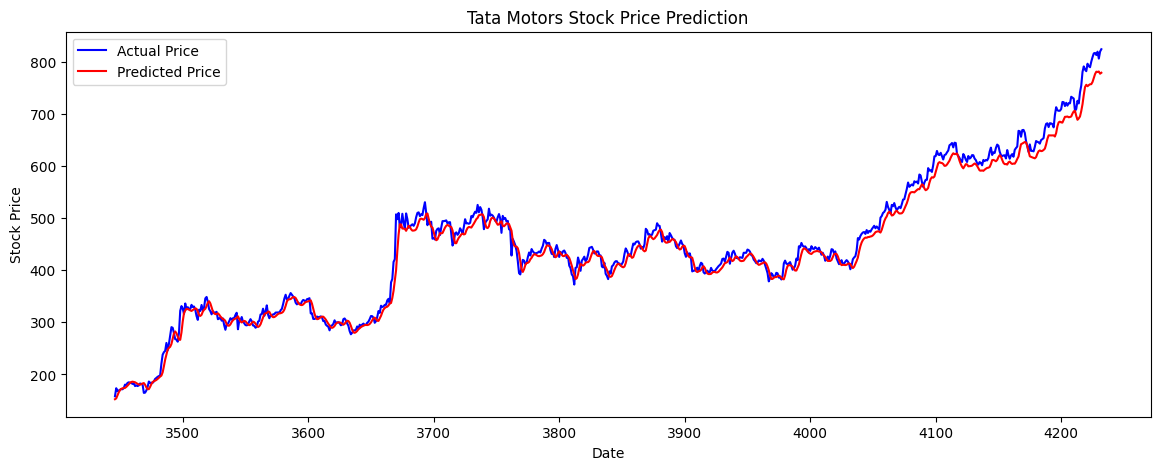

In [10]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

plt.figure(figsize=(14, 5))
plt.plot(df.index[train_size+60:], scaler.inverse_transform(test_data[60:]), color='blue', label='Actual Price')
plt.plot(df.index[train_size+60:], predictions, color='red', label='Predicted Price')
plt.title('Tata Motors Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [11]:
rmse = math.sqrt(mean_squared_error(scaler.inverse_transform(test_data[60:]), predictions))
print(f'Root Mean Square Error: {rmse}')

Root Mean Square Error: 16.86107447060451


In [12]:
future_days = 10

last_60_days = scaled_data[-60:]
future_predictions = []

for i in range(future_days):
    X_future = last_60_days.reshape(1, 60, 1)
    future_price = model.predict(X_future)

    future_predictions.append(future_price[0, 0])

    last_60_days = np.append(last_60_days, future_price)
    last_60_days = last_60_days[1:]

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

print(f"Future Stock Prices for next {future_days} days:")
print(future_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Future Stock Prices for next 10 days:
[[783.54346]
 [771.3208 ]
 [754.544  ]
 [737.9165 ]
 [723.1499 ]
 [710.48596]
 [699.5792 ]
 [689.95593]
 [681.21063]
 [673.0604 ]]
